                    Bank Fraud

             Objective 

The aim of this notebook is to perform explanatory data analysis by trying to uncover hidden patterns and stistical irregularities to detect anomalies. This will involve velocity mapping to identify those transactions with bot like behaviour, risk density to uncover distribution of anomalies in various occupations etc.

The target is identifying those transactions that have high probabilities of being fraud.

Below are python packages that I will use to analyse our dataset.

In [126]:
import pandas as pd 
import numpy as np 
import  matplotlib.pyplot as plt 
import seaborn as sns

In [127]:
#uploading our dataset
df = pd.read_csv('./bank_transactions_data_2.csv')
df.head().T

,0,1,2,3,4
TransactionID,TX000001,TX000002,TX000003,TX000004,TX000005
AccountID,AC00128,AC00455,AC00019,AC00070,AC00411
TransactionAmount,14.09,376.24,126.29,184.5,13.45
TransactionDate,2023-04-11 16:29:14,2023-06-27 16:44:19,2023-07-10 18:16:08,2023-05-05 16:32:11,2023-10-16 17:51:24
TransactionType,Debit,Debit,Debit,Debit,Credit
Location,San Diego,Houston,Mesa,Raleigh,Atlanta
DeviceID,D000380,D000051,D000235,D000187,D000308
IP Address,162.198.218.92,13.149.61.4,215.97.143.157,200.13.225.150,65.164.3.100
MerchantID,M015,M052,M009,M002,M091
Channel,ATM,ATM,Online,Online,Online


Our dataset has 16 columns divided into Identity (TransactionID and AccountId), demographic and social-economic status (CustomerOccupation, customer age), financial behaviour(AccountBalance, TransactionAmount, Channel), temporal data (TransactionDate, PreviousTransactionDate, TransactionDuration) and geographical (Location)

In [128]:
df.columns

Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate'],
      dtype='object')

The current data i.e TransactionDate is mislabelled as previous transaction date so renaming transaction date as previous transaction date to correct thet error.

In [129]:
df = df.rename(columns={'TransactionDate': 'PreviousTransactionDate', 'PreviousTransactionDate':'TransactionDate'})

In [130]:
#shape of the dataset
df.shape

(2512, 16)

This datase has 2,512 rows and 16 columns
             
             Checking Duplicates 

We will remove duplicates in our dataset since they may skew it making us to draw biased conclusions from it. AccountID is a unique value so useful in removing duplicated values. The shape of our dataset after removing them will proof their existence or not.

In [131]:
df.loc[~df['AccountID'].index.duplicated()]
df.shape

(2512, 16)

The shape of our dataset remained the same meaning there aren't any duplicates in this dataset

               Checking null values
null values in the dataset can result to biased analysis,  reduceed completeness of the dataset etc thus they require careful handling to  remove/modify them. We will check for null values in our dataset.


In [132]:
df.isnull().sum().sum()

np.int64(0)

There are no null values meaning our dataset has no missing values thus our model parameters won't suffer from attrrtion bias due to deleted entries.

                   Descriptive  Statistics 
These are statistical measures that provide the location (mean), spread(standard deviation) and shape of our dataset (counts). Minimum  (Min) helps with data quality if we saw a value that is physically impossible to be in our dataset.

The percentiles that is 25% - 75% show the interquantile range of various columns thus showing where mosts data points are highly distributed.

In [133]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [134]:
df.CustomerAge.describe()

count    2512.000000
mean       44.673965
std        17.792198
min        18.000000
25%        27.000000
50%        45.000000
75%        59.000000
max        80.000000
Name: CustomerAge, dtype: float64

In [135]:
df['customer_age_group'] = pd.cut(df['CustomerAge'], bins=[0, 20, 36, 50, 80], labels=['0-20', '20-36', '36-50', '51+'])

           What are transactions lablled anomalous due to 1 minute difference between current & previous transactions?

In [137]:
df_sorted = df.sort_values(by=['AccountID', 'TransactionDate'], ascending=True)
df_sorted['minute_difference'] = (df_sorted['TransactionDate'] - df_sorted['PreviousTransactionDate']).dt.total_seconds()/60 
user_stats = df_sorted.groupby('AccountID')['minute_difference'].agg(['mean', 'std']).rename(columns={'mean':'avg_gap', 'std': 'std_gap'})
user_transaction = df_sorted.groupby('AccountID')['TransactionAmount'].mean().rename('avg_transaction')
df_sorted = df_sorted.merge(user_stats, on='AccountID').merge(user_transaction, on='AccountID')
df_sorted['is_anomaly'] = ((df_sorted['minute_difference'] <  5) |  (df_sorted['minute_difference'] < (df_sorted['avg_gap'] - 2 * df_sorted['std_gap'])) & (df_sorted['TransactionAmount'] > df_sorted['avg_transaction']))
risk_table = df_sorted[df_sorted['is_anomaly'] == True][['AccountID', 'TransactionDate', 'CustomerOccupation', 'minute_difference', 'TransactionAmount']].copy()
risk_table['Reason'] = np.where(risk_table['minute_difference'] < 1, 'Bot threshold', 'Statistical Deviation')

risk_table.head(6)

,AccountID,TransactionDate,CustomerOccupation,minute_difference,TransactionAmount,Reason
455,AC00087,2024-11-04 08:11:00,Doctor,447255.500000,346.12,Statistical Deviation
642,AC00128,2024-11-04 08:06:38,Student,513518.433333,1397.59,Statistical Deviation
1271,AC00257,2024-11-04 08:10:44,Engineer,480420.150000,326.29,Statistical Deviation


There are only 3 transactions labelled as stistical anomalies since they don't reach the threshold of occuring in less than 1 minute to be classed as 'Bot behaviour'.

In [138]:
risk_table.shape

(3, 6)

       How  unusual transactions are distributed among various channels?

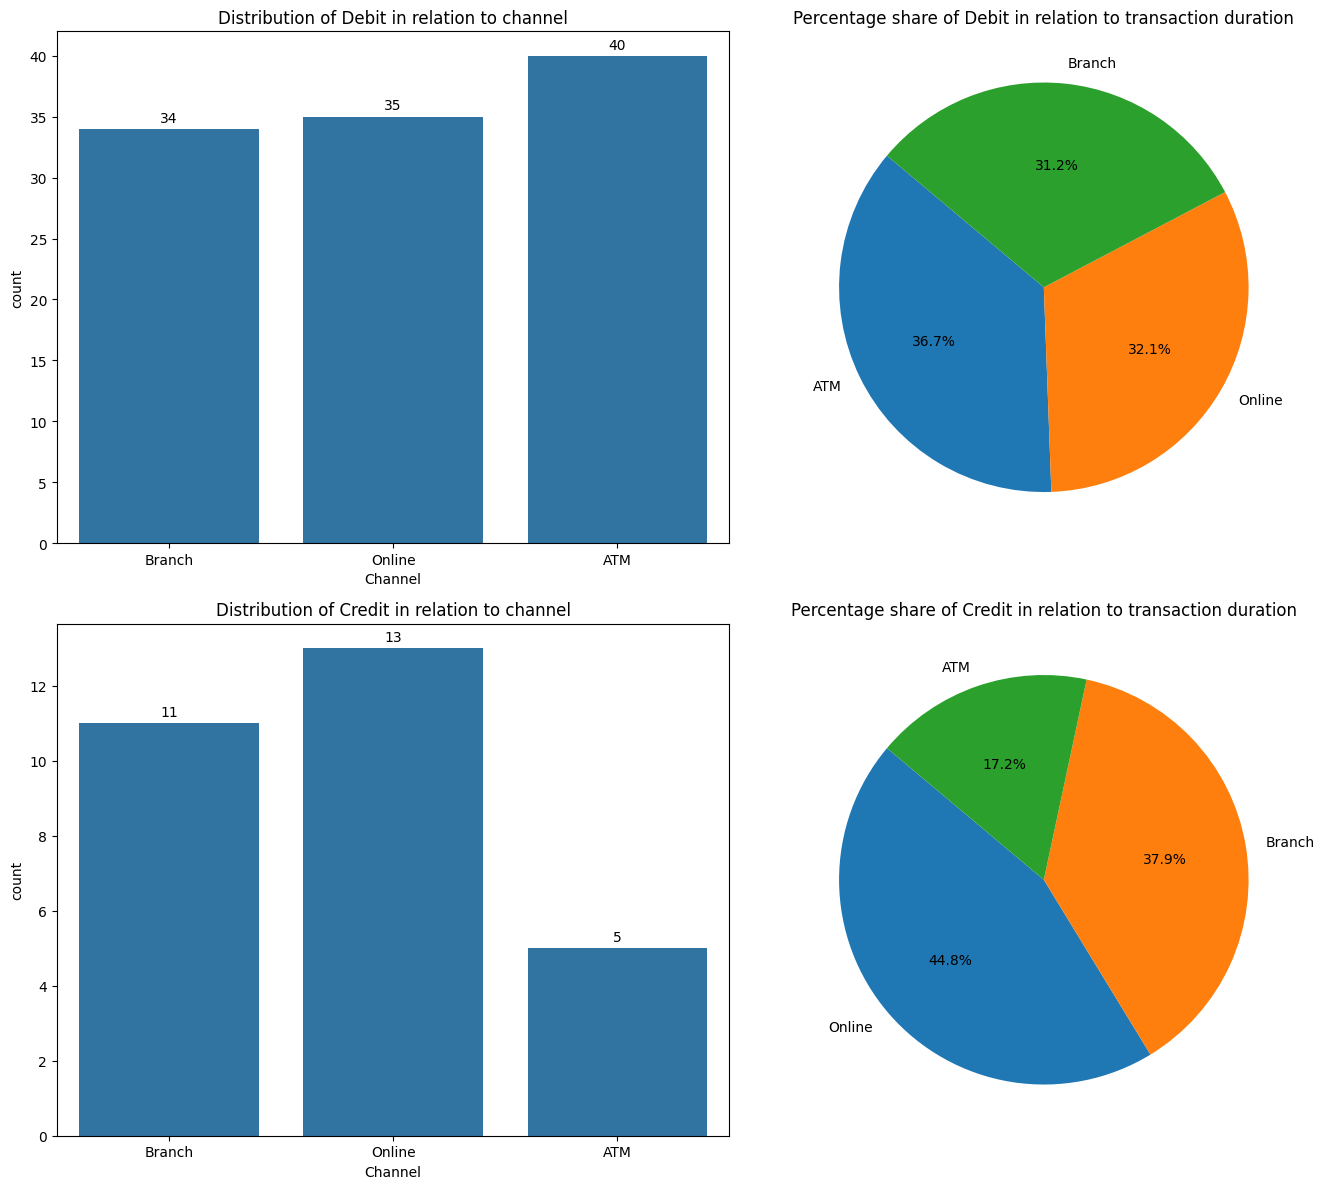

In [142]:
import seaborn as sns
transaction_types = df['TransactionType'].unique()
filteredData = [t for t in transaction_types if not df[df['TransactionType'] == t].empty]
fig, ax = plt.subplots(len(filteredData), 2, figsize = (14, 6 * len(filteredData)), squeeze=False)

for i , t_type in enumerate(filteredData):
    subset = df[df['TransactionType'] == t_type].copy()
    threshold =  subset['TransactionDuration'].mean() + 2 * subset['TransactionDuration'].std()
    anomalies = subset[subset['TransactionDuration'] > threshold]
    if not anomalies.empty:
        sns.countplot(data=anomalies, x='Channel', ax=ax[i, 0])
        ax[i, 0].set_title(f'Distribution of {t_type} in relation to channel')
        for container in ax[i, 0].containers:
            ax[i, 0].bar_label(container, padding=3) 
        
        channel_counts = anomalies['Channel'].value_counts()
        ax[i, 1].pie(channel_counts, labels=channel_counts.index, autopct= '%1.1f%%', startangle=140)
        ax[i, 1].set_title(f'Percentage share of {t_type} in relation to transaction duration')
plt.tight_layout()
plt.show()


In debit transactions:
ATM represents 38.7%  with 40 counts is the channel with the largest number of anomalous transactions, followed by online at 32.1% with 35 counts while Branch channel with 34 counts representing 31.2% of all transactions. 

In credit transactions:
Online channel with 44.8%  with 13 counts has the largest number of anomalous transactions, Branch at 37.9% with 11 counts comes second while ATM is the least with 5 counts repsenting 17.2% of the total transactions. 

                 conclusion

          What are the occupations with anomalous transactions amount?

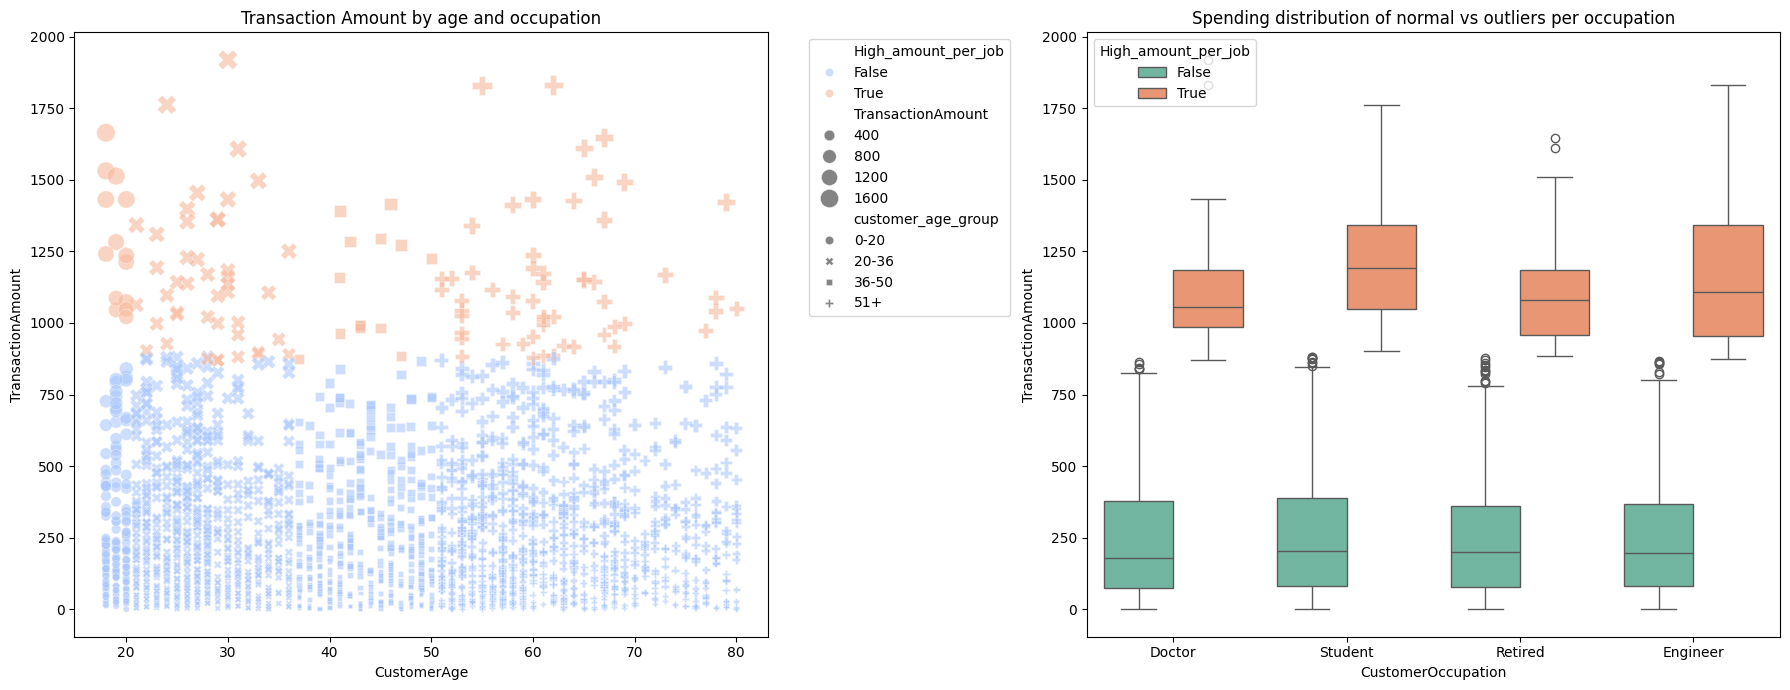

In [144]:

occuptaionThreshold = df.groupby('CustomerOccupation')['TransactionAmount'].transform(lambda x: x.quantile(0.95))

df['High_amount_per_job'] = df['TransactionAmount'] > occuptaionThreshold

fig, ax = plt.subplots(1, 2, figsize=(18, 7))
sns.scatterplot(data=df, x='CustomerAge', y='TransactionAmount', hue='High_amount_per_job', style='customer_age_group',size='TransactionAmount', sizes=(20, 200), alpha=0.6, ax=ax[0], palette='coolwarm')

ax[0].set_title('Transaction Amount by age and occupation')
ax[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

sns.boxplot(data=df,  x='CustomerOccupation', y='TransactionAmount', hue='High_amount_per_job', palette='Set2', ax=ax[1])
ax[1].set_title('Spending distribution of normal vs outliers per occupation')
plt.tight_layout()
plt.show()

In the scatterplot, Anomalous transactions  varry between amounts approximately $1000 - $200 with these transactions appearing across all customer age groups but customers aged 20 - 36 years being more notable.

The boxplot shows anomalous transactions have a high median at around $ 1000  with doctors and engineers having transactions that are skwed to the right. customers who are engineers and students have a high inter-quantile range meaning  the transactions ahve a high variablity with amounts ranging from around $750 at 25 percentile while $1750 at the 75 percentile. Customers with normal transaction have stable median at less tha $250.

    How are customers with anomalous transactions distributed in relation to occupation and age?

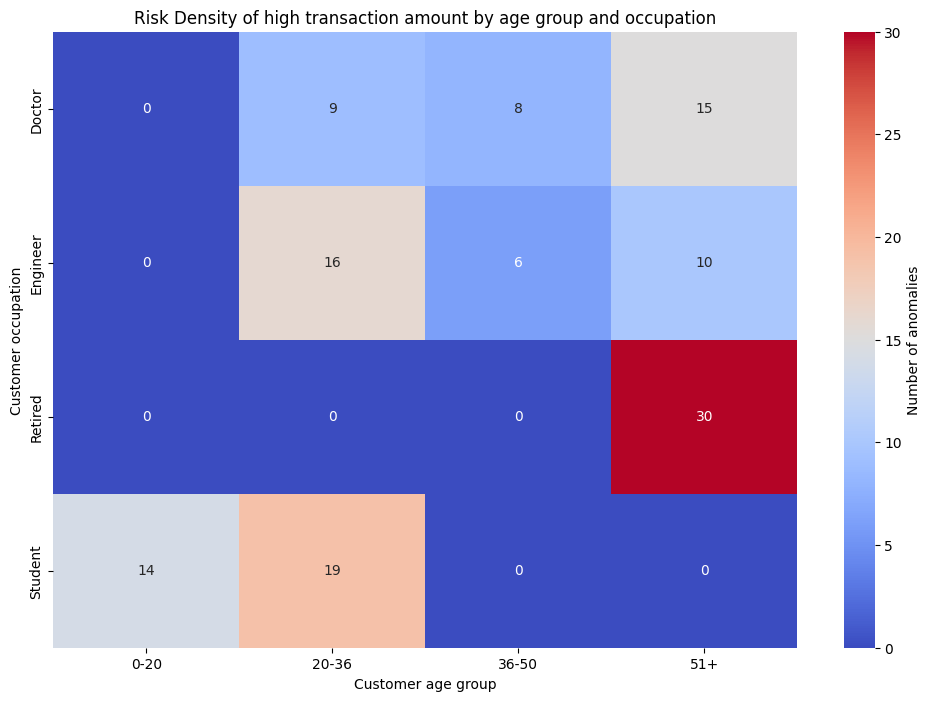

In [145]:
risk_density = df[df['High_amount_per_job'] == True].pivot_table(index='CustomerOccupation', columns='customer_age_group', values='TransactionAmount', aggfunc='count', observed=True).fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(risk_density, annot=True, fmt='.0f', cmap='coolwarm', cbar_kws={'label': 'Number of anomalies'})
plt.title('Risk Density of high transaction amount by age group and occupation')
plt.xlabel('Customer age group')
plt.ylabel('Customer occupation')
plt.show()

Of all occupations, students aged 0-36 years with 33 anomalies are the most significant, retired customers aged 51+ years with 30 anomalies come second, engineers aged 20-36 years with 16 while engineers aged  36-50 are the least with 6 anomalies.

Doctors aged 20 - 50 have the lowest number of anomalies at 8 while engineers aged 36-50 with 7 anomalies and 10 anomalies for ones aged 51+ are the low risk-segments.

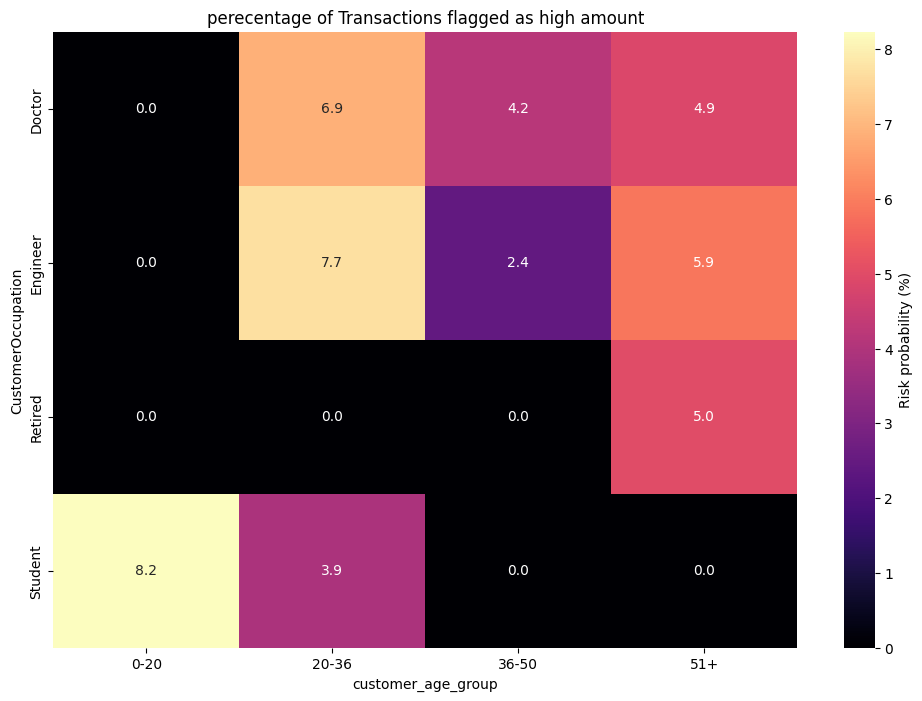

In [146]:
risk_counts = df[df['High_amount_per_job'] == True].groupby(['CustomerOccupation', 'customer_age_group'], observed=True).size().unstack(fill_value=0)
total_counts = df.groupby(['CustomerOccupation', 'customer_age_group'], observed=True).size().unstack(fill_value=0)
riskPercentages = ((risk_counts/total_counts)* 100).fillna(0)
plt.figure(figsize=(12, 8))
sns.heatmap(riskPercentages, annot=True, fmt='.1f', cmap='magma', cbar_kws={'label': 'Risk probability (%)'})
plt.title('perecentage of Transactions flagged as high amount')
plt.show()